# Derivatives Pricing: Vanilla and Barrier Options

Python implementation and cross-validation of three independent option pricing methods — closed-form **Black-Scholes**, **Monte Carlo simulation**, and **finite-difference PDE schemes** (explicit and Crank-Nicolson) — applied to European vanilla options and single-barrier options (knock-in / knock-out).

**Methods covered**
- Closed-form Black-Scholes pricing and Greeks (Delta, Gamma, Vega, Theta, Rho)
- Monte Carlo pricing of vanilla options, with convergence analysis and 95% confidence intervals
- Monte Carlo pricing of barrier options (down/up, in/out), with in-out parity and discretization-bias checks
- Finite-difference pricing via an explicit scheme, including a demonstration of numerical instability (CFL-type condition)
- Finite-difference pricing via the unconditionally stable Crank-Nicolson scheme, for both vanilla and barrier options
- Cross-validation between all three methods, and a study of each scheme's order of convergence

**Author:** Baptiste Secondi


## 1. Vanilla option payoff and P&L at expiry

Before pricing anything, a quick reminder of the payoff and profit-and-loss (P&L) profile of a long call and a long put at maturity, net of the premium paid.

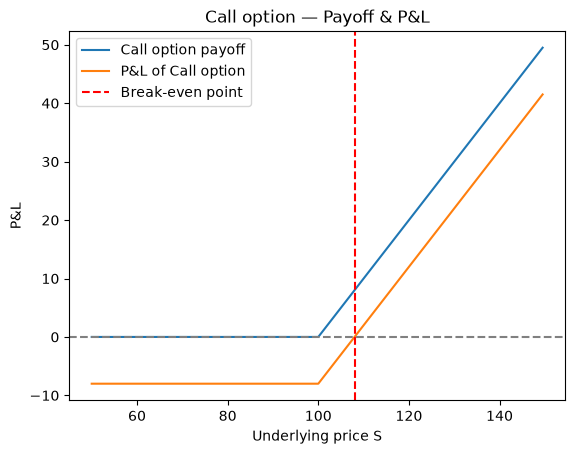

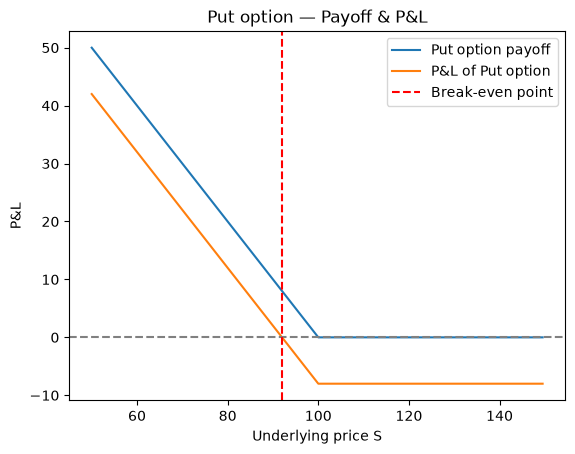

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def payoff_call(S, K):
    """European call payoff at maturity: max(S - K, 0)."""
    return np.maximum(S - K, 0)

def payoff_put(S, K):
    """European put payoff at maturity: max(K - S, 0)."""
    return np.maximum(K - S, 0)

def plot_option(payoff_func, S, K, premium, option_label, breakeven):
    """Plot the payoff and the P&L (payoff net of premium) of an option across a range of spot prices."""
    plt.plot(S, payoff_func(S, K), label=f'{option_label} payoff')
    plt.plot(S, payoff_func(S, K) - premium, label=f'P&L of {option_label}')
    plt.axhline(y=0, color='gray', linestyle='--')
    plt.axvline(x=breakeven, color='red', linestyle='--', label='Break-even point')
    plt.xlabel('Underlying price S')
    plt.ylabel('P&L')
    plt.title(f'{option_label} — Payoff & P&L')
    plt.legend()
    plt.show()

S_grid = np.arange(50, 150, 0.5)
K = 100
premium = 8

plot_option(payoff_call, S_grid, K, premium, 'Call option', breakeven=K + premium)
plot_option(payoff_put, S_grid, K, premium, 'Put option', breakeven=K - premium)


## 2. Closed-form Black-Scholes pricing and Greeks

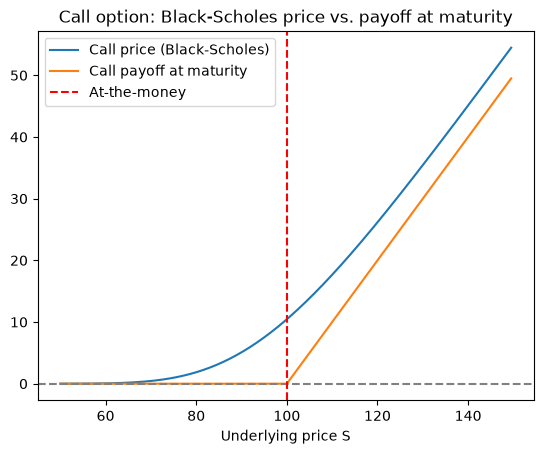

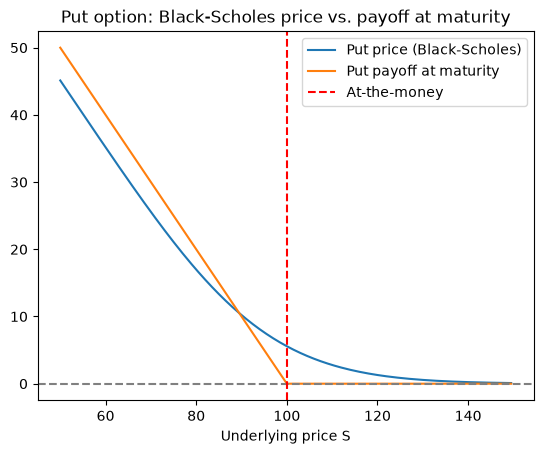

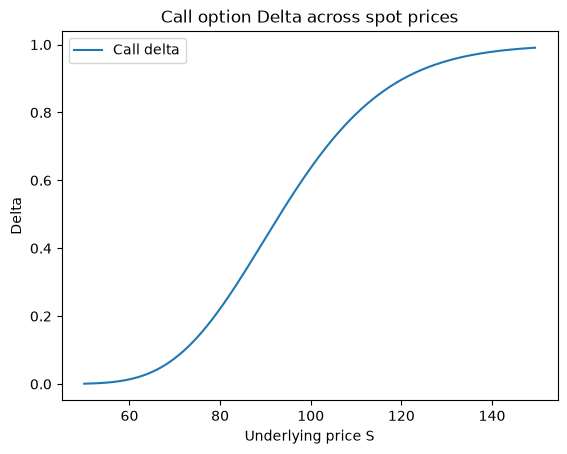

In [3]:
import scipy.stats
from math import exp, sqrt, log

def bs_price(S, K, T, r, sigma, option_type='call'):
    """Closed-form Black-Scholes price of a European vanilla option."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option_type == 'call':
        return S * scipy.stats.norm.cdf(d1) - K * np.exp(-r * T) * scipy.stats.norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * scipy.stats.norm.cdf(-d2) - S * scipy.stats.norm.cdf(-d1)

def bs_greeks(S, K, T, r, sigma, option_type='call'):
    """Closed-form Black-Scholes Greeks (Delta, Gamma, Vega, Theta, Rho)."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    greeks = {}
    if option_type == 'call':
        greeks['delta'] = scipy.stats.norm.cdf(d1)
        greeks['theta'] = (-(S * scipy.stats.norm.pdf(d1) * sigma) / (2 * np.sqrt(T))
                            - r * K * np.exp(-r * T) * scipy.stats.norm.cdf(d2))
        greeks['rho'] = K * T * np.exp(-r * T) * scipy.stats.norm.cdf(d2)
    else:
        greeks['delta'] = scipy.stats.norm.cdf(d1) - 1
        greeks['theta'] = (-(S * scipy.stats.norm.pdf(d1) * sigma) / (2 * np.sqrt(T))
                            + r * K * np.exp(-r * T) * scipy.stats.norm.cdf(-d2))
        greeks['rho'] = -K * T * np.exp(-r * T) * scipy.stats.norm.cdf(-d2)
    # Gamma and Vega are identical for calls and puts
    greeks['gamma'] = scipy.stats.norm.pdf(d1) / (S * sigma * np.sqrt(T))
    greeks['vega'] = S * scipy.stats.norm.pdf(d1) * np.sqrt(T)
    return greeks

S_grid = np.arange(50, 150, 0.5)
K, T, r, sigma = 100, 1, 0.05, 0.2

call_price = bs_price(S_grid, K, T, r, sigma, option_type='call')
put_price = bs_price(S_grid, K, T, r, sigma, option_type='put')

plt.plot(S_grid, call_price, label='Call price (Black-Scholes)')
plt.plot(S_grid, payoff_call(S_grid, K), label='Call payoff at maturity')
plt.axhline(y=0, color='gray', linestyle='--')
plt.axvline(x=K, color='red', linestyle='--', label='At-the-money')
plt.xlabel('Underlying price S')
plt.title('Call option: Black-Scholes price vs. payoff at maturity')
plt.legend()
plt.show()

plt.plot(S_grid, put_price, label='Put price (Black-Scholes)')
plt.plot(S_grid, payoff_put(S_grid, K), label='Put payoff at maturity')
plt.axhline(y=0, color='gray', linestyle='--')
plt.axvline(x=K, color='red', linestyle='--', label='At-the-money')
plt.xlabel('Underlying price S')
plt.title('Put option: Black-Scholes price vs. payoff at maturity')
plt.legend()
plt.show()

delta_call = bs_greeks(S_grid, K, T, r, sigma, option_type='call')['delta']
plt.plot(S_grid, delta_call, label='Call delta')
plt.xlabel('Underlying price S')
plt.ylabel('Delta')
plt.title('Call option Delta across spot prices')
plt.legend()
plt.show()


## 3. Monte Carlo pricing of vanilla options

Monte Carlo call price : 10.4205
Monte Carlo put price  : 5.6122
Put-call parity check  : C - P = 4.8083  vs.  S0 - K*exp(-rT) = 4.8771


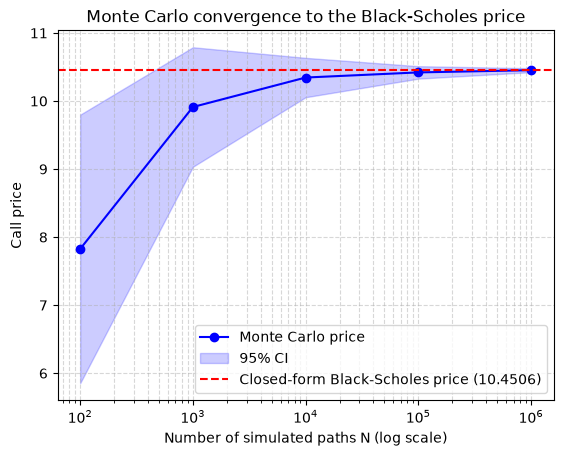

In [4]:
def mc_price_vanilla(S0, K, T, r, sigma, option_type='call', n_paths=100_000, seed=None):
    """
    Monte Carlo price of a European vanilla option under the Black-Scholes model,
    simulating the terminal price S_T directly (no need to simulate the full path).
    Returns the discounted price estimate, its standard error, and a 95% confidence interval.
    """
    rng = np.random.default_rng(seed)
    Z = rng.standard_normal(n_paths)
    S_T = S0 * np.exp((r - sigma**2 / 2) * T + sigma * np.sqrt(T) * Z)

    if option_type == 'call':
        payoff = np.maximum(S_T - K, 0)
    else:
        payoff = np.maximum(K - S_T, 0)

    discounted_payoff = np.exp(-r * T) * payoff
    price = discounted_payoff.mean()
    se = discounted_payoff.std(ddof=0) / np.sqrt(n_paths)
    ci_95 = (float(price - 1.96 * se), float(price + 1.96 * se))

    return float(price), float(se), ci_95


S0, K, T, r, sigma = 100, 100, 1, 0.05, 0.2

call_mc = mc_price_vanilla(S0, K, T, r, sigma, option_type='call', n_paths=100_000, seed=42)[0]
put_mc = mc_price_vanilla(S0, K, T, r, sigma, option_type='put', n_paths=100_000, seed=42)[0]
parity_lhs = call_mc - put_mc
forward_rhs = S0 - K * exp(-r * T)

print(f"Monte Carlo call price : {call_mc:.4f}")
print(f"Monte Carlo put price  : {put_mc:.4f}")
print(f"Put-call parity check  : C - P = {parity_lhs:.4f}  vs.  S0 - K*exp(-rT) = {forward_rhs:.4f}")

# Convergence of the Monte Carlo estimate to the closed-form Black-Scholes price
bs_call_price = bs_price(S0, K, T, r, sigma, option_type='call')

n_paths_grid = [10**i for i in range(2, 7)]
prices, lower_bounds, upper_bounds = [], [], []
for n in n_paths_grid:
    price, se, ci = mc_price_vanilla(S0, K, T, r, sigma, option_type='call', n_paths=n, seed=42)
    prices.append(price)
    lower_bounds.append(ci[0])
    upper_bounds.append(ci[1])

plt.plot(n_paths_grid, prices, marker='o', label='Monte Carlo price', color='blue')
plt.fill_between(n_paths_grid, lower_bounds, upper_bounds, color='blue', alpha=0.2, label='95% CI')
plt.axhline(y=bs_call_price, color='red', linestyle='--', label=f'Closed-form Black-Scholes price ({bs_call_price:.4f})')
plt.xscale('log')
plt.xlabel('Number of simulated paths N (log scale)')
plt.ylabel('Call price')
plt.title('Monte Carlo convergence to the Black-Scholes price')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()


## 4. Monte Carlo pricing of barrier options

Barrier options require simulating the full path (not just the terminal price), since the payoff depends on whether the underlying ever crosses a barrier level B before maturity. The engine below simulates each path on a discrete monitoring grid, vectorized across the path dimension in memory-bounded chunks so that both the number of paths and the number of monitoring steps can be large without allocating a single oversized array.

Vanilla Black-Scholes call price    : 10.4506
Down-and-out + down-and-in (parity) : 10.4526


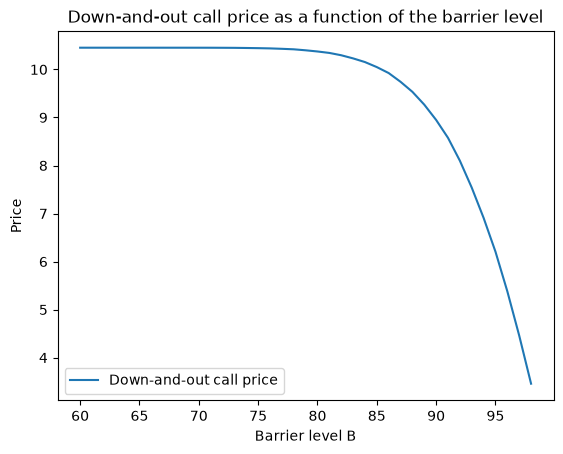

In [7]:
def mc_price_barrier(S0, K, T, r, sigma, barrier, barrier_type, option_type='call',
                      n_paths=50_000, n_steps=252, seed=None, max_floats_per_chunk=20_000_000):
    """
    Monte Carlo price of a single-barrier European option (down/up, in/out), simulated on a
    discrete monitoring grid of n_steps dates. Paths are generated in memory-bounded chunks
    (vectorized within each chunk) so that n_paths and n_steps can both be large without
    allocating a single n_paths x n_steps array upfront.
    """
    rng = np.random.default_rng(seed)
    delta_t = T/n_steps
    estimator = 0
    estimator2 = 0
    for i in range (n_paths):
        S_t = S0
        S_T = [S_t]
        Z = rng.standard_normal(n_steps)
        for j in range (n_steps):
            S_t = S_t * exp((r - (sigma**2)/2)*delta_t + sigma * sqrt(delta_t) * Z[j])
            S_T.append(S_t)

        minimum = np.min(S_T)
        maximum = np.max(S_T)

        if barrier_type == 'down-and-out':
            if minimum > barrier :
                if option_type == 'call':
                    payoff = max(S_T[-1]-K,0)
                else :
                    payoff = max(K-S_T[-1],0)
            else :
                payoff = 0
        
        elif barrier_type == 'down-and-in':
            if minimum <= barrier :
                if option_type == 'call':
                    payoff = max(S_T[-1]-K,0)
                else :
                    payoff = max(K-S_T[-1],0)
            else :
                payoff = 0

        
        elif barrier_type == 'up-and-out':
            if maximum < barrier :
                if option_type == 'call':
                    payoff = max(S_T[-1]-K,0)
                else :
                    payoff = max(K-S_T[-1],0)
            else :
                payoff = 0


        elif barrier_type == 'up-and-in':
            if maximum >= barrier :
                if option_type == 'call':
                    payoff = max(S_T[-1]-K,0)
                else :
                    payoff = max(K-S_T[-1],0)
            else :
                payoff = 0
        
        estimator += payoff
        estimator2 += payoff**2
    
    estimator = estimator * exp(-r*T) * 1/n_paths
    estimator2 = estimator2 * exp(-2*r*T) * 1/n_paths
    se = sqrt((estimator2 - estimator**2)/n_paths)

    return estimator,se


# --- In-out parity check: a down-and-out + a down-and-in of the same strike/maturity
#     must reconstitute the vanilla option (exactly one of the two barrier events happens) ---
S0, K, T, r, sigma, barrier = 100, 100, 1, 0.05, 0.2, 80

vanilla_call = bs_price(S0, K, T, r, sigma, option_type='call')
down_and_out = mc_price_barrier(S0, K, T, r, sigma, barrier, barrier_type='down-and-out', option_type='call', n_paths=50_000, n_steps=252, seed=42)
down_and_in = mc_price_barrier(S0, K, T, r, sigma, barrier, barrier_type='down-and-in', option_type='call', n_paths=50_000, n_steps=252, seed=42)

print(f"Vanilla Black-Scholes call price    : {vanilla_call:.4f}")
print(f"Down-and-out + down-and-in (parity) : {down_and_out[0] + down_and_in[0]:.4f}")

# --- Sensitivity to the barrier level B ---
S0, K, T, r, sigma = 100, 100, 1, 0.05, 0.2
barrier_grid = np.arange(60, 99, 1)
prices = [mc_price_barrier(S0, K, T, r, sigma, barrier=b, barrier_type='down-and-out', option_type='call', n_paths=50_000, n_steps=252, seed=42)[0] for b in barrier_grid]

plt.plot(barrier_grid, prices, label='Down-and-out call price')
plt.xlabel('Barrier level B')
plt.ylabel('Price')
plt.title('Down-and-out call price as a function of the barrier level')
plt.legend()
plt.show()


**Barrier level sensitivity (down-and-out call price vs. B):** As the barrier B moves further from the spot price (S₀=100), the down-and-out call price converges toward the vanilla Black-Scholes price (≈10.45), since the barrier becomes increasingly unlikely to be breached over the option's life. Conversely, as B approaches S₀, the knock-out probability rises sharply and the price collapses toward zero — the holder becomes increasingly likely to lose the entire payoff, even in paths that would have finished in the money at maturity.

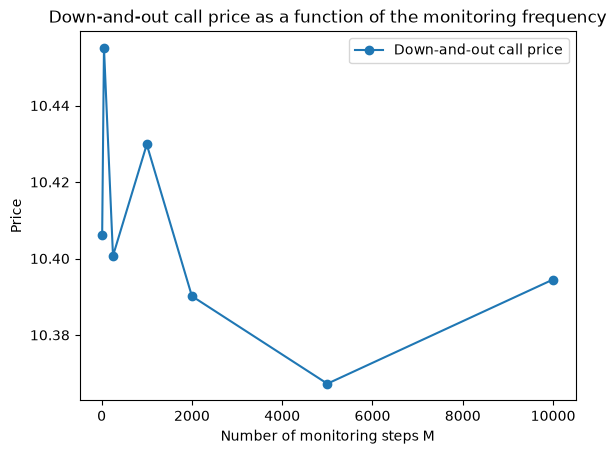

In [8]:
S0, K, T, r, sigma, barrier = 100, 100, 1, 0.05, 0.2, 80
n_steps_grid = [12, 52, 252, 1000,2000,5000,10000]
prices = [mc_price_barrier(S0, K, T, r, sigma, barrier, barrier_type='down-and-out', option_type='call', n_paths=100_000, n_steps=n, seed=42)[0] for n in n_steps_grid]

plt.plot(n_steps_grid, prices, marker='o', label='Down-and-out call price')
plt.xlabel('Number of monitoring steps M')
plt.ylabel('Price')
plt.title('Down-and-out call price as a function of the monitoring frequency')
plt.legend()
plt.show()


**Number of monitoring steps sensitivity (down-and-out call price vs. M):** Since the barrier is only checked at M discrete dates, a coarse grid (small M) misses intra-period crossings that a continuously-monitored contract would have knocked out on, inflating the simulated price. As M increases, discrete monitoring better approximates continuous monitoring, the missed-crossing bias shrinks, and the price drifts downward toward its true (lower) continuously-monitored value. At low path counts this effect can be partly masked by Monte Carlo sampling noise, but it becomes clearly visible with N=100,000 paths, most notably in the marked drop between M=52 and M=252.

## 5. Finite differences — explicit scheme for vanilla options

The Black-Scholes PDE can also be solved directly on a discretized (S, t) grid. The explicit scheme below marches backward in time from the terminal payoff, updating each interior grid point from its three neighbours at the next time step. It is simple to implement, but only conditionally stable (see the instability demonstration below).

In [6]:
def fd_price_explicit_vanilla(S0, K, T, r, sigma, option_type, S_max, n_S, n_t):
    """
    Prices a vanilla option using an explicit finite-difference scheme on a uniform (S, t) grid.
    Returns the interpolated price at S0, along with the grid (S) and terminal values (V) for plotting.
    Only conditionally stable: dt must be small enough relative to dS (CFL-type condition).
    """
    dt = T / n_t
    dS = S_max / n_S

    # 1. Build the spatial grid
    S = np.linspace(0, S_max, n_S + 1)

    # Pre-compute the tridiagonal coefficients ('i' = grid index of interior points, 1..n_S-1)
    i = np.arange(1, n_S)
    a = 0.5 * dt * (sigma**2 * i**2 - r * i)  # sub-diagonal coefficient
    b = 1.0 - dt * (sigma**2 * i**2 + r)      # main diagonal coefficient
    c = 0.5 * dt * (sigma**2 * i**2 + r * i)  # super-diagonal coefficient

    # 2. Terminal condition: the payoff at maturity
    if option_type == 'call':
        V = np.maximum(S - K, 0)
    else:
        V = np.maximum(K - S, 0)

    # 3. March backward in time
    for n in range(1, n_t + 1):
        t = T - n * dt
        V_new = np.zeros_like(V)

        # 4. Vectorized update of the interior points
        V_new[1:-1] = a * V[:-2] + b * V[1:-1] + c * V[2:]

        # 5. Boundary conditions
        if option_type == 'call':
            V_new[0] = 0
            # S_max is assumed large enough that the call is worth its forward intrinsic value there
            V_new[-1] = S_max - K * np.exp(-r * (T - t))
        else:
            V_new[0] = K * np.exp(-r * (T - t))
            V_new[-1] = 0

        V = V_new

    # 6. Linear interpolation to read the price exactly at S0
    price = np.interp(S0, S, V)
    return float(price), S, V


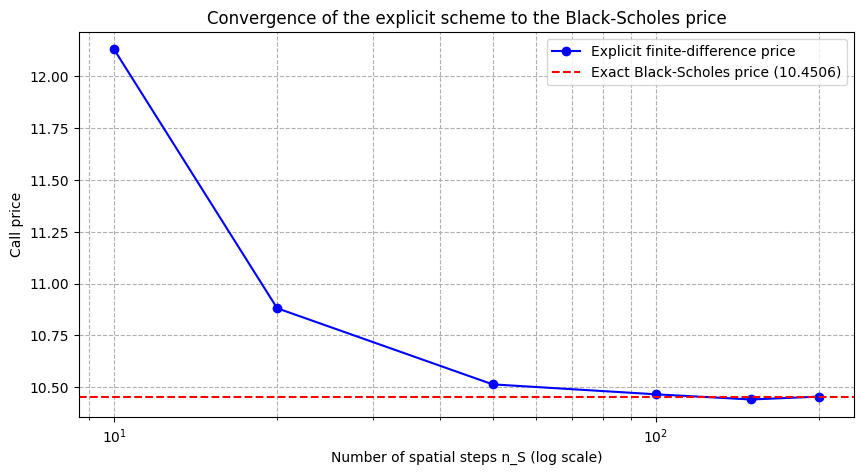

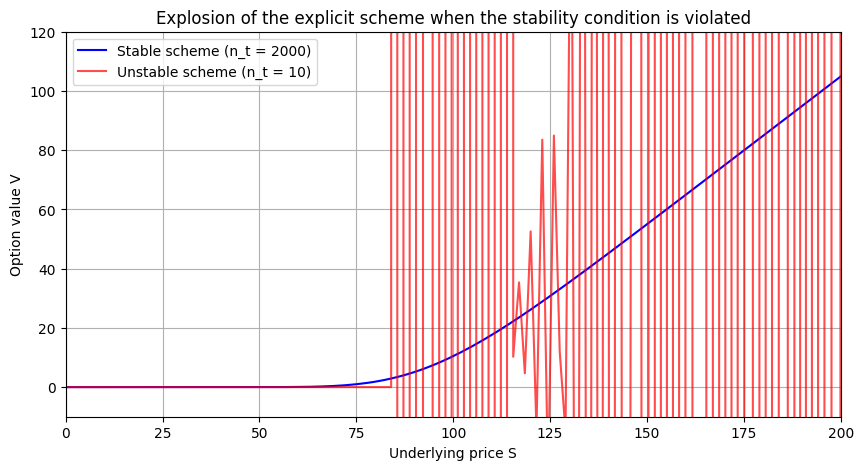

In [7]:
S0, K, T, r, sigma = 100, 100, 1, 0.05, 0.2
S_max = 300
option_type = 'call'

exact_price = bs_price(S0, K, T, r, sigma, option_type)

n_S_values = [10, 20, 50, 100, 150, 200]
n_t_fixed = 10_000  # large enough to isolate the spatial discretization error
fd_prices = [fd_price_explicit_vanilla(S0, K, T, r, sigma, option_type, S_max, n_S, n_t_fixed)[0] for n_S in n_S_values]

plt.figure(figsize=(10, 5))
plt.plot(n_S_values, fd_prices, marker='o', color='blue', label='Explicit finite-difference price')
plt.axhline(exact_price, color='red', linestyle='--', label=f'Exact Black-Scholes price ({exact_price:.4f})')
plt.xscale('log')
plt.xlabel('Number of spatial steps n_S (log scale)')
plt.ylabel('Call price')
plt.title('Convergence of the explicit scheme to the Black-Scholes price')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

# Numerical instability when the stability condition is violated
n_S = 200
n_t_stable = 2000     # satisfies the stability condition
n_t_unstable = 10      # violates it (dt too large relative to dS)

_, S_stable, V_stable = fd_price_explicit_vanilla(S0, K, T, r, sigma, option_type, S_max, n_S, n_t_stable)
_, S_unstable, V_unstable = fd_price_explicit_vanilla(S0, K, T, r, sigma, option_type, S_max, n_S, n_t_unstable)

plt.figure(figsize=(10, 5))
plt.plot(S_stable, V_stable, color='blue', label=f'Stable scheme (n_t = {n_t_stable})')
plt.plot(S_unstable, V_unstable, color='red', alpha=0.7, label=f'Unstable scheme (n_t = {n_t_unstable})')
plt.xlim(0, 200)  # zoom in around the strike K
plt.ylim(-10, 120)
plt.xlabel('Underlying price S')
plt.ylabel('Option value V')
plt.title('Explosion of the explicit scheme when the stability condition is violated')
plt.legend()
plt.grid(True)
plt.show()


## 6. Finite differences — explicit scheme for barrier options

In [8]:
def fd_price_barrier_explicit(S0, K, T, r, sigma, barrier, S_max, n_S, n_t, barrier_type, option_type):
    """
    Prices a down-and-out or up-and-out option with an explicit finite-difference scheme,
    on a grid truncated exactly at the barrier so the knock-out boundary condition (V=0) falls on a
    grid point. (Knock-in prices are obtained by in-out parity against the vanilla price, not here.)
    """
    dt = T / n_t  # dt must stay small relative to dS for stability

    if barrier_type == 'down-and-out':
        dS = (S_max - barrier) / n_S
        S = np.linspace(barrier, S_max, n_S + 1)
    elif barrier_type == 'up-and-out':
        dS = barrier / n_S
        S = np.linspace(0, barrier, n_S + 1)
    else:
        raise ValueError("barrier_type must be 'down-and-out' or 'up-and-out'")

    # Pre-compute the tridiagonal coefficients
    a = 0.5 * dt * (sigma**2 * (S[1:-1]**2) / (dS**2) - r * S[1:-1] / dS)  # sub-diagonal
    b = 1.0 - dt * (sigma**2 * (S[1:-1]**2) / (dS**2) + r)                # main diagonal
    c = 0.5 * dt * (sigma**2 * (S[1:-1]**2) / (dS**2) + r * S[1:-1] / dS) # super-diagonal

    if option_type == 'call':
        V = np.maximum(S - K, 0)
    else:
        V = np.maximum(K - S, 0)

    for n in range(1, n_t + 1):
        t = T - n * dt
        V_new = np.zeros_like(V)
        V_new[1:-1] = a * V[:-2] + b * V[1:-1] + c * V[2:]

        # The barrier boundary is always 0 (knock-out); the far boundary keeps the vanilla condition
        if barrier_type == 'down-and-out':
            if option_type == 'call':
                V_new[0] = 0
                V_new[-1] = S_max - K * np.exp(-r * (T - t))
            else:
                V_new[0] = 0
                V_new[-1] = 0
        else:  # up-and-out
            if option_type == 'call':
                V_new[0] = 0
                V_new[-1] = 0
            else:
                V_new[0] = K * np.exp(-r * (T - t))
                V_new[-1] = 0
        V = V_new

    price = np.interp(S0, S, V)
    return float(price), S, V


S0, K, T, r, sigma, barrier = 100, 100, 1, 0.05, 0.2, 40
S_max, n_S, n_t = 300, 200, 4000

fd_price = fd_price_barrier_explicit(S0, K, T, r, sigma, barrier, S_max, n_S, n_t, barrier_type='down-and-out', option_type='call')[0]
mc_price_ref = mc_price_barrier(S0, K, T, r, sigma, barrier, barrier_type='down-and-out', option_type='call', n_paths=50_000, n_steps=252, seed=42)

print(f"Finite-difference price : {fd_price:.4f}")
print(f"Monte Carlo price       : {mc_price_ref[0]:.4f}  (SE = {mc_price_ref[1]:.4f})")


Finite-difference price : 10.4508
Monte Carlo price       : 10.4526  (SE = 0.0660)


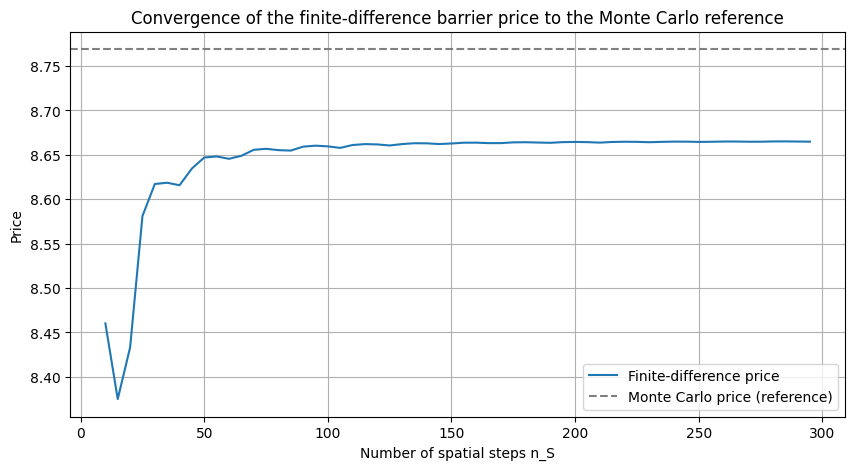

In [9]:
S0, K, T, r, sigma, barrier = 100, 100, 1, 0.05, 0.2, 90
S_max, n_t = 300, 10_000
n_S_grid = np.arange(10, 300, 5)

fd_prices = [fd_price_barrier_explicit(S0, K, T, r, sigma, barrier, S_max, n_S, n_t, barrier_type='down-and-out', option_type='call')[0] for n_S in n_S_grid]
mc_reference = mc_price_barrier(S0, K, T, r, sigma, barrier, barrier_type='down-and-out', option_type='call', n_paths=100_000, n_steps=5000, seed=42)[0]

plt.figure(figsize=(10, 5))
plt.plot(n_S_grid, fd_prices, label='Finite-difference price')
plt.axhline(mc_reference, color='gray', linestyle='--', label='Monte Carlo price (reference)')
plt.xlabel('Number of spatial steps n_S')
plt.ylabel('Price')
plt.title('Convergence of the finite-difference barrier price to the Monte Carlo reference')
plt.legend()
plt.grid(True)
plt.show()


Increasing the number of Monte Carlo monitoring steps reduces the barrier's time-discretization bias: the reference estimate moves down from about 8.95 to about 8.74 simply by refining n_steps, converging toward the finite-difference (continuous-monitoring) price above.

## 7. Cross-check: finite differences vs. Monte Carlo across barrier levels

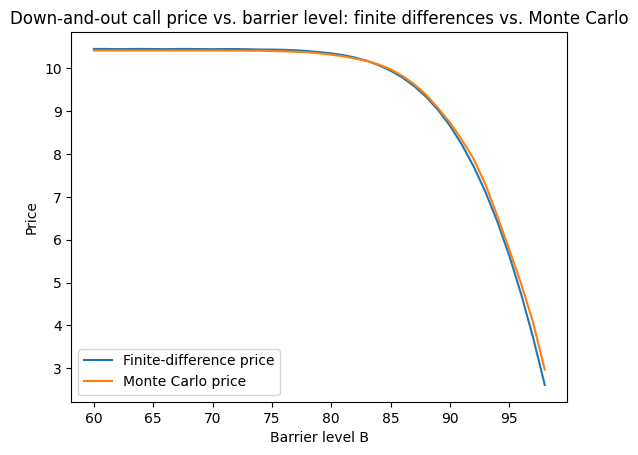

In [10]:
S0, K, T, r, sigma = 100, 100, 1, 0.05, 0.2
barrier_grid = np.arange(60, 99, 1)
S_max, n_S, n_t = 300, 200, 10_000

fd_prices = [fd_price_barrier_explicit(S0, K, T, r, sigma, b, S_max, n_S, n_t, barrier_type='down-and-out', option_type='call')[0] for b in barrier_grid]
# A lighter Monte Carlo budget is enough here: this cell is a visual cross-check against the
# finite-difference reference, not the convergence study itself (see Section 4 for that).
mc_prices = [mc_price_barrier(S0, K, T, r, sigma, b, barrier_type='down-and-out', option_type='call', n_paths=20_000, n_steps=1000, seed=42)[0] for b in barrier_grid]

plt.plot(barrier_grid, fd_prices, label='Finite-difference price')
plt.plot(barrier_grid, mc_prices, label='Monte Carlo price')
plt.xlabel('Barrier level B')
plt.ylabel('Price')
plt.title('Down-and-out call price vs. barrier level: finite differences vs. Monte Carlo')
plt.legend()
plt.show()


## 8. The Crank-Nicolson scheme (unconditionally stable)

The explicit scheme above is only conditionally stable — as shown, too large a time step makes it explode. The Crank-Nicolson scheme averages the explicit and implicit updates, which makes it unconditionally stable, at the cost of solving a tridiagonal linear system at each time step.

In [11]:
import scipy.linalg

def fd_price_cn_vanilla(S0, K, T, r, sigma, option_type, S_max, n_S, n_t):
    """
    Prices a vanilla option with the Crank-Nicolson finite-difference scheme (unconditionally stable),
    by solving a tridiagonal linear system at each time step.
    """
    dS = S_max / n_S
    dt = T / n_t

    S = np.linspace(0, S_max, n_S + 1)
    i = np.arange(1, n_S)

    alpha = 0.25 * dt * (sigma**2 * i**2 - r * i)
    beta = -0.5 * dt * (sigma**2 * i**2 + r)
    gamma = 0.25 * dt * (sigma**2 * i**2 + r * i)

    if option_type == 'call':
        V = np.maximum(S - K, 0)
    else:
        V = np.maximum(K - S, 0)

    # Banded matrix for the implicit (left-hand) side of the Crank-Nicolson system
    ab = np.zeros((3, n_S + 1))
    ab[0, 2:] = -gamma       # super-diagonal: coefficient of V_{i+1}
    ab[1, 1:-1] = 1 - beta   # diagonal: coefficient of V_i
    ab[2, :-2] = -alpha      # sub-diagonal: coefficient of V_{i-1}
    ab[1, 0] = 1.0           # Dirichlet boundary at i=0
    ab[1, -1] = 1.0          # Dirichlet boundary at i=n_S

    for n in range(n_t):
        tau = (n + 1) * dt
        d = np.zeros(n_S + 1)
        d[1:-1] = alpha * V[:-2] + (1 + beta) * V[1:-1] + gamma * V[2:]
        if option_type == 'call':
            d[0], d[-1] = 0.0, S_max - K * np.exp(-r * tau)
        else:
            d[0], d[-1] = K * np.exp(-r * tau), 0.0

        V = scipy.linalg.solve_banded((1, 1), ab, d)

    price = np.interp(S0, S, V)
    return float(price), S, V


In [12]:
def fd_price_cn_barrier(S0, K, T, r, sigma, barrier, barrier_type, option_type, S_max, n_S, n_t):
    """
    Prices a down-and-out or up-and-out option with the Crank-Nicolson scheme, on a grid
    truncated at the barrier. (Knock-in prices follow from in-out parity, not from this function.)
    """
    dt = T / n_t

    # 1. Rebuild the grid so the barrier falls exactly on a grid boundary
    if barrier_type == 'down-and-out':
        S_low, S_high = barrier, S_max     # barrier sits at the low boundary (i=0)
        barrier_at_low = True
    elif barrier_type == 'up-and-out':
        S_low, S_high = 0.0, barrier       # barrier sits at the high boundary (i=n_S); S_max unused here
        barrier_at_low = False
    else:
        raise ValueError("barrier_type must be 'down-and-out' or 'up-and-out' — knock-in follows from parity, not this function")

    dS = (S_high - S_low) / n_S
    S = np.linspace(S_low, S_high, n_S + 1)

    # 2. Coefficients expressed directly in S_i (not in the grid index i), since the grid
    #    no longer necessarily starts at 0 here: x = S_i / dS plays the role that "i" played
    #    in the vanilla scheme above.
    x = S / dS
    alpha_full = 0.25 * dt * (sigma**2 * x**2 - r * x)
    beta_full = -0.5 * dt * (sigma**2 * x**2 + r)
    gamma_full = 0.25 * dt * (sigma**2 * x**2 + r * x)
    alpha, beta, gamma = alpha_full[1:-1], beta_full[1:-1], gamma_full[1:-1]

    # Terminal condition: vanilla payoff, truncated to the barrier-restricted domain
    if option_type == 'call':
        V = np.maximum(S - K, 0.0)
    else:
        V = np.maximum(K - S, 0.0)

    ab = np.zeros((3, n_S + 1))
    ab[0, 2:] = -gamma
    ab[1, 1:-1] = 1 - beta
    ab[2, :-2] = -alpha
    ab[1, 0] = 1.0
    ab[1, -1] = 1.0

    for n in range(n_t):
        tau = (n + 1) * dt
        d = np.zeros(n_S + 1)
        d[1:-1] = alpha * V[:-2] + (1 + beta) * V[1:-1] + gamma * V[2:]

        # 3. The barrier-side boundary is always 0 (knock-out); the other boundary keeps
        #    the same condition as the vanilla scheme
        if barrier_at_low:
            d[0] = 0.0
            d[-1] = S_max - K * np.exp(-r * tau) if option_type == 'call' else 0.0
        else:
            d[0] = 0.0 if option_type == 'call' else K * np.exp(-r * tau)
            d[-1] = 0.0

        V = scipy.linalg.solve_banded((1, 1), ab, d)

    price = np.interp(S0, S, V)
    return float(price), S, V


In [13]:
S0, K, T, r, sigma = 100, 100, 1, 0.05, 0.20
S_max, n_S, n_t = 4 * K, 200, 200

# --- 1. Vanilla: Crank-Nicolson vs. closed-form Black-Scholes ---
price_cn, _, _ = fd_price_cn_vanilla(S0, K, T, r, sigma, 'call', S_max, n_S, n_t)
price_bs = bs_price(S0, K, T, r, sigma, 'call')

print("=== Vanilla ===")
print(f"Crank-Nicolson : {price_cn:.4f}")
print(f"Black-Scholes  : {price_bs:.4f}")
print(f"Difference     : {abs(price_cn - price_bs):.5f}")

# --- 2. Down-and-out barrier (B=90) ---
B = 90
price_do, _, _ = fd_price_cn_barrier(S0, K, T, r, sigma, B, 'down-and-out', 'call', S_max, n_S, n_t)
print(f"\n=== Down-and-out barrier (B={B}) ===")
print(f"Crank-Nicolson price : {price_do:.4f}")

# --- 3. In-out parity, cross-checked against an independent Monte Carlo estimate ---
# Note: with the barrier only 10% below the spot (B=90, S0=100), the discrete-monitoring bias
# from Section 4 needs a much finer grid than usual to become negligible here -- n_steps=5000
# (fine enough when B=80) still leaves a visible downward bias for B=90, so n_steps=20,000 is
# used for this specific cross-check.
price_di_by_parity = price_cn - price_do
mc_di_price, mc_di_se = mc_price_barrier(S0, K, T, r, sigma, B, 'down-and-in', 'call', n_paths=100_000, n_steps=20_000, seed=42)

print("\n=== In-out parity (down-and-in) ===")
print(f"Crank-Nicolson vanilla - Crank-Nicolson down-and-out : {price_di_by_parity:.4f}")
print(f"Monte Carlo (independent reference)                  : {mc_di_price:.4f} +/- {1.96*mc_di_se:.4f} (95% CI)")
print(f"Difference                                            : {abs(price_di_by_parity - mc_di_price):.4f}  (should fall within the CI)")

# --- 4. Stability check: re-use a time-step count small enough to have broken the explicit scheme ---
n_t_small = 10
price_cn_small_nt, _, _ = fd_price_cn_vanilla(S0, K, T, r, sigma, 'call', S_max, n_S, n_t_small)

print("\n=== Stability (deliberately small n_t) ===")
print("Explicit scheme : diverges / oscillates at this n_t (see Section 5)")
print(f"Crank-Nicolson  : {price_cn_small_nt:.4f}  (should stay close to {price_bs:.4f}, not diverge)")


=== Vanilla ===
Crank-Nicolson : 10.4407
Black-Scholes  : 10.4506
Difference     : 0.00989

=== Down-and-out barrier (B=90) ===
Crank-Nicolson price : 8.6628



=== In-out parity (down-and-in) ===
Crank-Nicolson vanilla - Crank-Nicolson down-and-out : 1.7778
Monte Carlo (independent reference)                  : 1.8088 +/- 0.0366 (95% CI)
Difference                                            : 0.0310  (should fall within the CI)

=== Stability (deliberately small n_t) ===
Explicit scheme : diverges / oscillates at this n_t (see Section 5)
Crank-Nicolson  : 10.4166  (should stay close to 10.4506, not diverge)


**Note:** at n_steps=5000 (fine enough for the B=80 case studied in Section 4), the Monte Carlo estimate here was still measurably downward-biased against the Crank-Nicolson / parity estimate. With the barrier only 10% below the spot (B=90 vs. S0=100), paths spend much more time close to the barrier, so the discrete-monitoring bias from Section 4 decays more slowly and needs a much finer grid (n_steps=20,000) to become negligible -- a good reminder that the "how fine is fine enough" answer from a sensitivity study at one barrier level doesn't automatically transfer to another.

## 9. Order of convergence: explicit vs. Crank-Nicolson

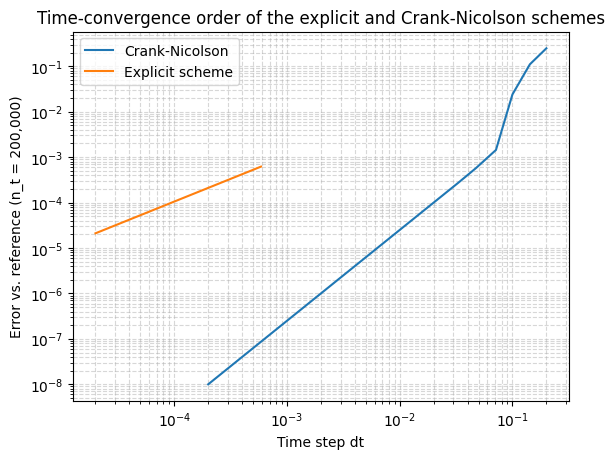

In [14]:
S0, K, T, r, sigma = 100, 100, 1, 0.05, 0.20
S_max, n_S = 4 * K, 200
option_type = 'call'

# Quasi-exact reference: Crank-Nicolson on the same spatial grid, with a very large n_t
n_t_ref = 200_000
price_ref = fd_price_cn_vanilla(S0, K, T, r, sigma, option_type, S_max, n_S, n_t_ref)[0]

n_t_cn = np.unique(np.logspace(np.log10(5), np.log10(5000), 20).astype(int))
n_t_explicit = np.unique(np.logspace(np.log10(1700), np.log10(50000), 20).astype(int))

price_cn = [fd_price_cn_vanilla(S0, K, T, r, sigma, option_type, S_max, n_S, nt)[0] for nt in n_t_cn]
price_explicit = [fd_price_explicit_vanilla(S0, K, T, r, sigma, option_type, S_max, n_S, nt)[0] for nt in n_t_explicit]

error_cn = np.abs(np.array(price_cn) - price_ref)
error_explicit = np.abs(np.array(price_explicit) - price_ref)

dt_cn = T / n_t_cn
dt_explicit = T / n_t_explicit

plt.loglog(dt_cn, error_cn, label='Crank-Nicolson')
plt.loglog(dt_explicit, error_explicit, label='Explicit scheme')
plt.xlabel('Time step dt')
plt.ylabel(f'Error vs. reference (n_t = {n_t_ref:,})')
plt.title('Time-convergence order of the explicit and Crank-Nicolson schemes')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()


To study the time-convergence order of the two finite-difference schemes, I fix the spatial grid (n_S) and vary only the number of time steps n_t. Comparing directly against the closed-form Black-Scholes price would not isolate the temporal error alone: a fixed spatial grid introduces its own truncation error, a constant bias independent of n_t, and for Crank-Nicolson this spatial bias can partially cancel the growing temporal error as dt increases, producing a misleading dip instead of a clean power-law trend. To remove the spatial bias from the comparison, I build a quasi-exact reference price on the same spatial grid, computed with a very large n_t (200,000) so its own temporal error is negligible. Comparing every price to this reference instead of to the closed-form solution isolates the temporal discretization error only, since both prices share the same spatial bias, which cancels out in the difference. The resulting log-log plot shows a clean straight line of slope ≈1 for the explicit scheme and ≈2 for Crank-Nicolson, confirming their expected first- and second-order convergence in time.

## Summary

- All three pricing methods (Black-Scholes, Monte Carlo, finite differences) agree with each other within their respective error bounds, for both vanilla and barrier options.
- Put-call parity and barrier in-out parity both hold, providing an internal consistency check independent of any closed-form benchmark.
- The explicit finite-difference scheme is only conditionally stable and can diverge if the time step is too large relative to the spatial step; Crank-Nicolson is unconditionally stable and converges to second order in time, versus first order for the explicit scheme.

**Next steps** (companion project, in progress): extending this framework beyond Black-Scholes to stochastic and local volatility models (Heston, Dupire) and to path-dependent structured payoffs such as autocallables.